In [3]:
!pip install matplotlib

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

In [40]:
data = pd.read_csv('netflix_titles_clean.csv')

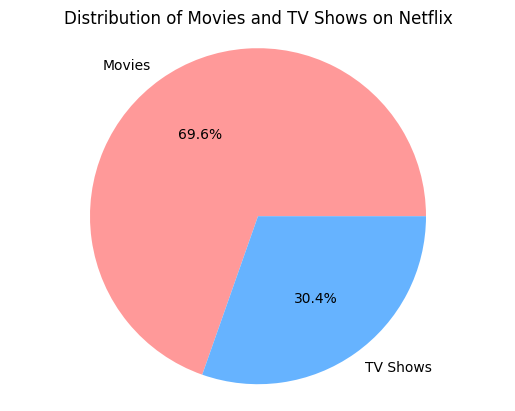

In [9]:
# plotting movies vs tv shows

labels = ['Movies', 'TV Shows']
# finding the number of movies and tv shows in the dataset

sizes = [len(data[data['type'] == 'Movie']), len(data[data['type'] == 'TV Show'])] 
colors = ['#ff9999','#66b3ff']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Distribution of Movies and TV Shows on Netflix')
plt.axis('equal')
plt.show()


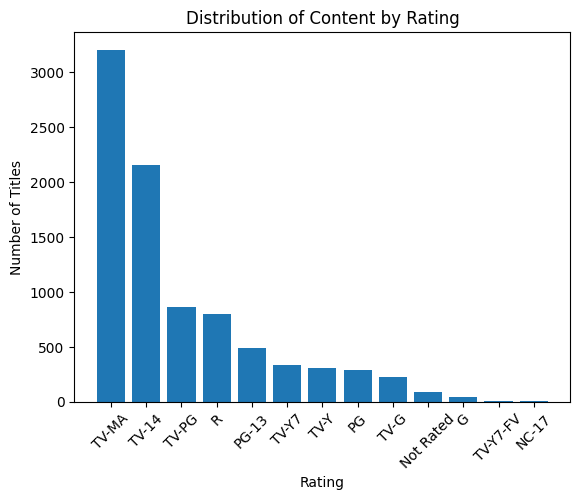

In [10]:
# content by rating
rating_counts = data['rating'].value_counts() # returns a series with the count of each unique value in the 'rating' column

plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.title('Distribution of Content by Rating')
plt.xticks(rotation=45)
plt.show()

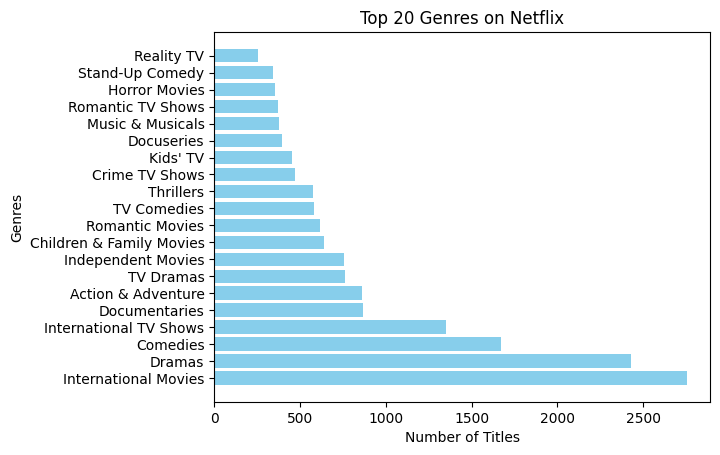

In [15]:
# Top 20 Genres

genre_counts = data['listed_in'].str.split(', ').explode().value_counts().head(20) # 
plt.barh(genre_counts.index, genre_counts.values, color='skyblue')
plt.xlabel('Number of Titles')
plt.ylabel('Genres')
plt.title('Top 20 Genres on Netflix')
plt.show()

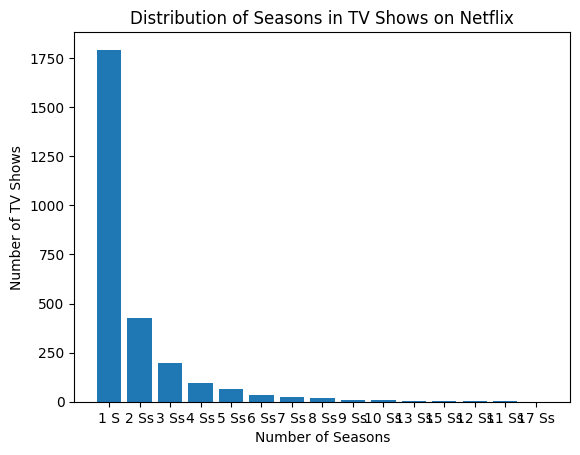

In [18]:
# bar chart of seasons in tv shows
tv_shows = data[data['type'] == 'TV Show']
season_counts = tv_shows['duration'].value_counts()
# print(season_counts)
#changing the index to be more readable for the plot (1 season -> 1S) and so on 
season_counts.index = season_counts.index.str.replace('Season', 'S').str.replace('Seasons', 'S') 
plt.bar(season_counts.index, season_counts.values) # 
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.title('Distribution of Seasons in TV Shows on Netflix')
plt.show()

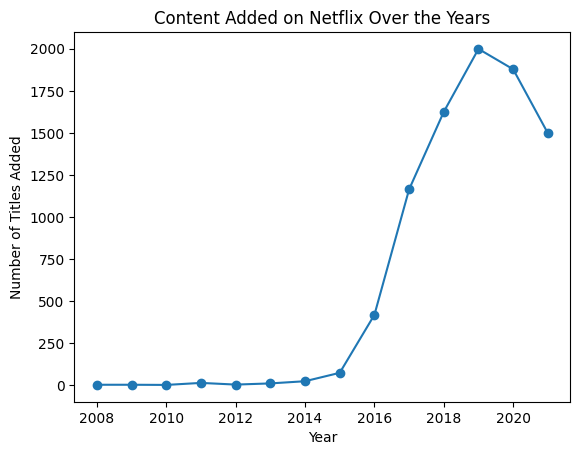

In [23]:
# line chart of content added over the years
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce')
content_over_time = data.groupby(data['date_added'].dt.year).size()
# print(content_over_time)
plt.plot(content_over_time.index, content_over_time.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.title('Content Added on Netflix Over the Years')
plt.show()

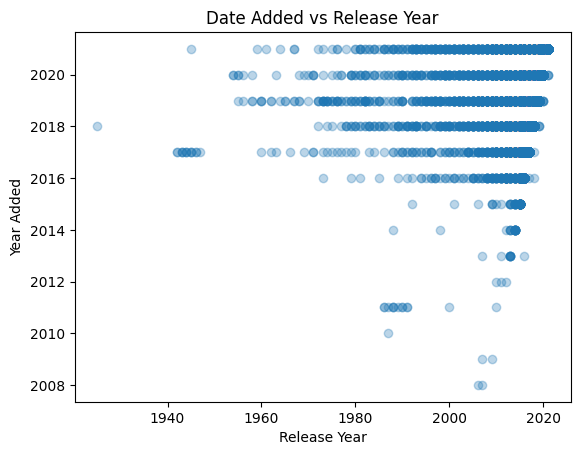

In [28]:
# scatter plot for date added vs releae year 
data['release_year'] = pd.to_numeric(data['release_year'], errors='coerce')
plt.scatter(data['release_year'], data['date_added'].dt.year, alpha=0.3)
plt.xlabel('Release Year')
plt.ylabel('Year Added')
plt.title('Date Added vs Release Year')
plt.show()

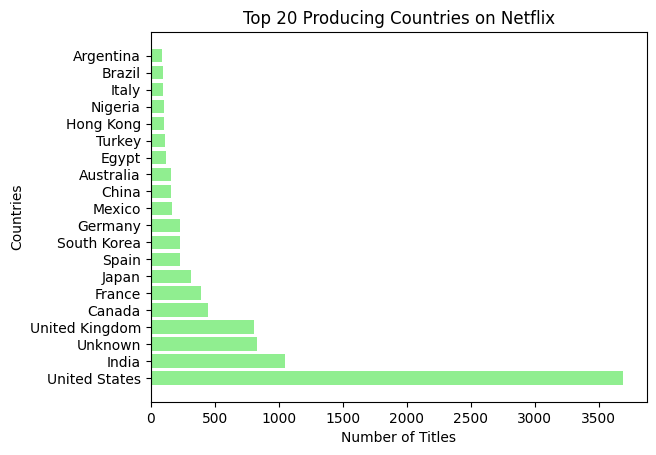

In [29]:
# top 20 producing countries
country_counts = data['country'].str.split(', ').explode().value_counts().head(20)
plt.barh(country_counts.index, country_counts.values, color='lightgreen')
plt.xlabel('Number of Titles')
plt.ylabel('Countries')
plt.title('Top 20 Producing Countries on Netflix')
plt.show()

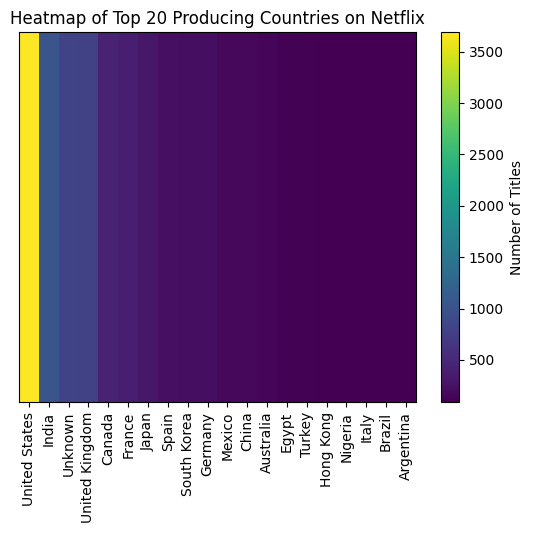

In [41]:
country_counts = data['country'].str.split(', ').explode().value_counts().head(20)
plt.imshow([country_counts.values], cmap='viridis', aspect='auto')
plt.yticks([])
plt.xticks(range(len(country_counts.index)), country_counts.index, rotation=90)
plt.colorbar(label='Number of Titles')
plt.title('Heatmap of Top 20 Producing Countries on Netflix')
plt.show()

type                                                Movie  TV Show
country                                                           
, France, Algeria                                       1        0
, South Korea                                           0        1
Argentina                                              38       18
Argentina, Brazil, France, Poland, Germany, Den...      1        0
Argentina, Chile                                        2        0


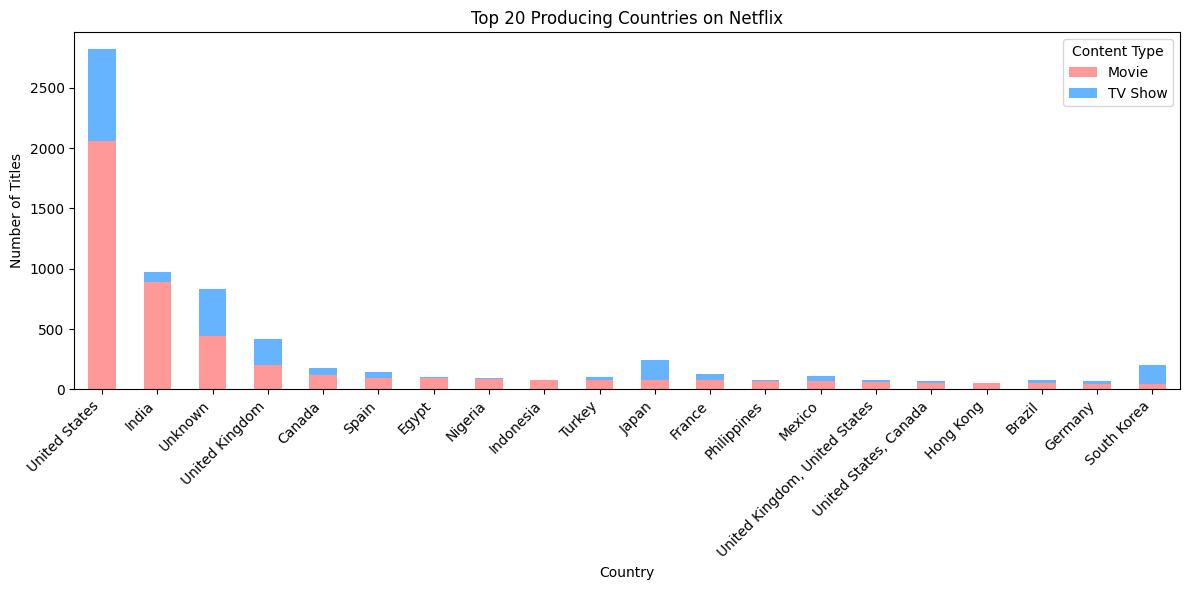

In [ ]:
# which country produces more movies vs tv shows
# country_type_counts = data.groupby(['country', 'type']).size().unstack(fill_value=0)
# print(country_type_counts.head())
# country_type_counts = country_type_counts.sort_values(by='Movie', ascending=False).head(20)
country_type_counts = data[]
country_type_counts.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ff9999','#66b3ff'])
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.title('Top 20 Producing Countries on Netflix')
plt.legend(title='Content Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()